In [172]:
import pandas as pd
import numpy as np
import scipy.stats as st
import statsmodels.formula.api as smf
import statsmodels.stats as sms
import statsmodels.api as sm

import matplotlib.pyplot as plt
import plotly.express as px
import plotly.io as pio
import seaborn as sns
import altair as alt

from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import PolynomialFeatures

In [2]:
kc = pd.read_csv('kc_house_data.csv')

In [3]:
kc.dtypes

id                 int64
date              object
price            float64
bedrooms           int64
bathrooms        float64
sqft_living        int64
sqft_lot           int64
floors           float64
waterfront         int64
view               int64
condition          int64
grade              int64
sqft_above         int64
sqft_basement      int64
yr_built           int64
yr_renovated       int64
zipcode            int64
lat              float64
long             float64
sqft_living15      int64
sqft_lot15         int64
dtype: object

In [4]:
kc['date'] = pd.to_datetime(kc.date)

In [5]:
sqft_to_sqmeters = 0.09290303997

In [6]:
kc = kc.astype({'sqft_living': float, 'sqft_lot': float, 
                'sqft_above': float, 'sqft_basement': float,
                'sqft_living15': float, 'sqft_lot15': float})

In [7]:
kc.loc[:,['sqft_living', 'sqft_lot', 'sqft_above', 'sqft_basement', 'sqft_living15', 'sqft_lot15']] =\
kc.loc[:,['sqft_living', 'sqft_lot', 'sqft_above', 'sqft_basement', 'sqft_living15', 'sqft_lot15']] * sqft_to_sqmeters

In [8]:
kc.columns = ['id', 'date', 'price', 'bedrooms', 'bathrooms', 'sqm_living',
       'sqm_lot', 'floors', 'waterfront', 'view', 'condition', 'grade',
       'sqm_above', 'sqm_basement', 'yr_built', 'yr_renovated', 'zipcode',
       'lat', 'long', 'sqm_living15', 'sqm_lot15']

In [9]:
kc = kc.loc[:, ['id', 'date', 'price', 
            'floors', 'bedrooms', 'bathrooms', 
            'yr_built', 'yr_renovated',
            'waterfront', 'view', 'condition', 'grade', 
            'sqm_living', 'sqm_lot', 
            'sqm_above', 'sqm_basement',
            'sqm_living15', 'sqm_lot15',
            'lat', 'long']]

In [10]:
kc.loc[kc.yr_renovated == 0, 'yr_renovated'] = np.nan
kc.loc[kc.sqm_basement == 0, 'sqm_basement'] = np.nan

In [11]:
alt.data_transformers.disable_max_rows()
alt.renderers.enable('default')

RendererRegistry.enable('default')

In [12]:
base = pio.templates["simple_white"]
custom_template = base.layout.template

custom_template.layout.update(
    margin=dict(l=50, r=0, t=20, b=50),
    xaxis=dict(
        title_standoff=0,
        ticks="outside",
        showgrid=True,
        gridcolor='#bbb'
    ),
    yaxis=dict(
        title_standoff=0,
        ticks="outside",
        showgrid=True,
        gridcolor='#bbb'
    ),
    colorscale=dict(
        sequential=px.colors.sequential.Inferno
    ),
    colorway=px.colors.qualitative.T10
)

pio.templates["tight"] = custom_template
pio.templates.default = "tight"

Exploratory data analysis

In [13]:
kc.id.value_counts().value_counts()

count
1    21260
2      175
3        1
Name: count, dtype: int64

In [14]:
px.histogram(kc, 'date', height=400
).update_traces(xbins_start=kc.date.min(),
                xbins_end=kc.date.max(),
                xbins_size='D',
                marker_cornerradius=20
).update_xaxes(dtick=7*24*60*60*1000,
               minor_dtick=24*60*60*1000,
               minor_showgrid=True,
               tickangle=-65,
               ticks='outside',
               tick0='2014-05-05'
).update_layout(margin=dict(b=70))

In [15]:
px.histogram(kc, x='price', height=200
).update_traces(
    xbins_size=10**4,
    marker_cornerradius=10
)

In [16]:
px.histogram(kc, x='price', height=200, log_x=True
).update_traces(
    xbins_size=10**4,
    marker_cornerradius=10
)

In [17]:
pd.DataFrame(kc.floors.value_counts()).T

floors,1.0,2.0,1.5,3.0,2.5,3.5
count,10680,8241,1910,613,161,8


In [18]:
pd.DataFrame(kc.bedrooms.value_counts()).T

bedrooms,3,4,2,5,6,1,7,0,8,9,10,11,33
count,9824,6882,2760,1601,272,199,38,13,13,6,3,1,1


In [19]:
pd.DataFrame(kc.bathrooms.value_counts()).T.iloc[:,:15]

bathrooms,2.50,1.00,1.75,2.25,2.00,1.50,2.75,3.00,3.50,3.25,3.75,4.00,4.50,4.25,0.75
count,5380,3852,3048,2047,1930,1446,1185,753,731,589,155,136,100,79,72


In [20]:
pd.DataFrame(kc.bathrooms.value_counts()).T.iloc[:,15:]

bathrooms,4.75,5.00,5.25,0.00,5.50,1.25,6.00,0.50,5.75,6.75,8.00,6.50,6.25,7.75,7.50
count,23,21,13,10,10,9,6,4,4,2,2,2,2,1,1


In [21]:
kc[['waterfront', 'view', 'condition', 'grade']].apply(lambda x: x.value_counts()).T.fillna('')

,0,1,2,3,4,5,6,7,8,9,10,11,12,13
waterfront,21450.0,163.0,,,,,,,,,,,,
view,19489.0,332.0,963.0,510.0,319.0,,,,,,,,,
condition,,30.0,172.0,14031.0,5679.0,1701.0,,,,,,,,
grade,,1.0,,3.0,29.0,242.0,2038.0,8981.0,6068.0,2615.0,1134.0,399.0,90.0,13.0


Text(0.5, 0, 'square meters')

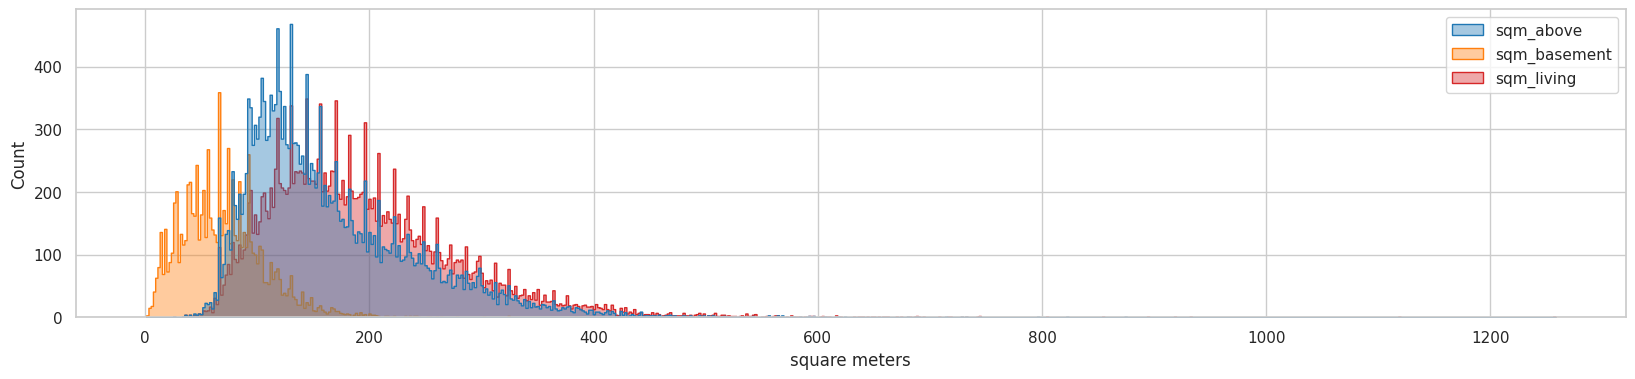

In [22]:
sns.set(rc={"figure.figsize":(20,4)})
sns.set_style('whitegrid')
sns.histplot(kc[['sqm_above', 'sqm_basement', 'sqm_living']],
             binwidth=2, palette=['#1f77b4', '#ff7f0e', '#d62728'], # binrange=(0,400),
             multiple='layer', element='step', alpha=0.4, linewidth=1)
plt.xlabel('square meters')

In [23]:
px.histogram(kc, x='sqm_lot', height=200, log_x=True
).update_traces(xbins_size=16, marker_cornerradius=10)

In [24]:
kc.id.count()

np.int64(21613)

In [25]:
kc.loc[kc.sqm_living==kc.sqm_above,'sqm_above'].count()

np.int64(13126)

In [26]:
kc.loc[kc.sqm_above==kc.sqm_basement,'sqm_basement'].count()

np.int64(551)

In [27]:
kc.sqm_basement.isna().sum()

np.int64(13126)

In [28]:
(kc.sqm_basement.isna() == np.where(kc.sqm_living==kc.sqm_above, 1, 0)).sum()

np.int64(21613)

Text(0.5, 0, 'year built')

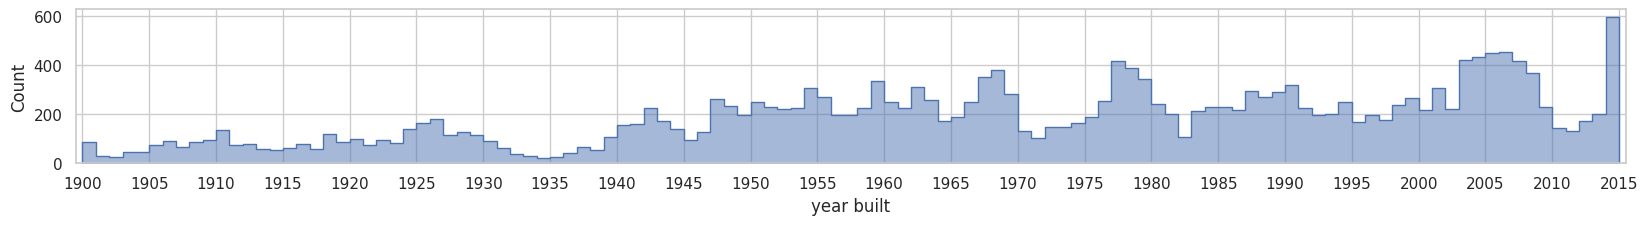

In [29]:
sns.set(rc={"figure.figsize":(20,2)})
sns.set_style('whitegrid')
sns.histplot(data=kc.yr_built, binrange=(1900,2015), binwidth=1, element='step', alpha=0.5)
plt.locator_params(axis='x', nbins=40)
plt.xlim(1899.5,2015.5)
plt.xlabel('year built')

Text(0.5, 0, 'year of renovation')

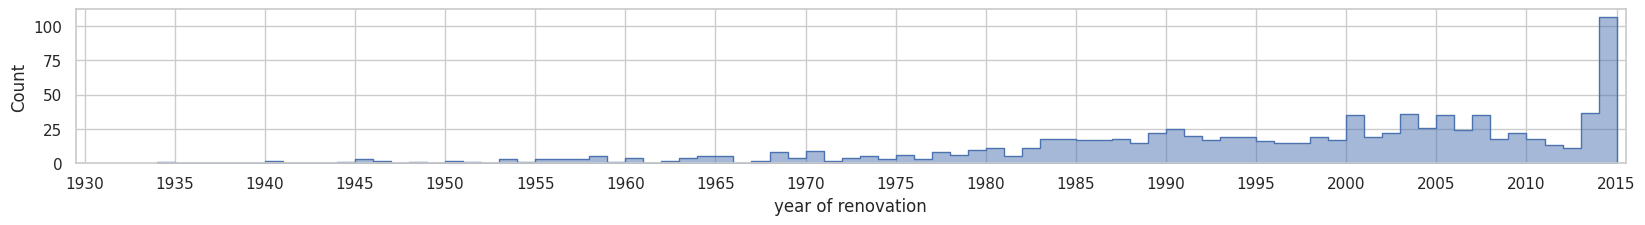

In [30]:
sns.set(rc={"figure.figsize":(20,2)})
sns.set_style('whitegrid')
sns.histplot(data=kc.yr_renovated, binrange=(1934,2015), binwidth=1, element='step', alpha=0.5)
plt.locator_params(axis='x', nbins=30)
plt.xlim(1929.5,2015.5)
plt.xlabel('year of renovation')

In [31]:
kc.yr_renovated.notna().sum()

np.int64(914)

In [32]:
# px.scatter_map(kc, lat='lat', lon='long', size='sqm_living', size_max=10, zoom=9, template='plotly_dark',
#                color='price', map_style='carto-darkmatter', color_continuous_scale='plasma'
#                ).update_layout(margin=dict(l=0,r=0,b=0,t=0)
#                ).show(renderer='png', width=1500, height=500)

##### Regressions

In [33]:
# alt.Chart(kc).mark_circle(
#     size=20, opacity=0.75, tooltip=True
# ).encode(
#     alt.X(alt.repeat("column"), type='quantitative').scale(zero=False).axis(format='~s'),
#     alt.Y(alt.repeat("row"), type='quantitative').scale(zero=False).axis(format='~s'),
#     alt.Color('condition:N').scale(scheme='tableau10')
# ).properties(
#     width=200,
#     height=200
# ).repeat(
#     row=['price', 'grade', 'sqm_living', 'sqm_lot', 'yr_built', 'yr_renovated'],
#     column=['price', 'grade', 'sqm_living', 'sqm_lot', 'yr_built', 'yr_renovated']
# ).configure_facet(spacing=0
# ).configure_legend(symbolOpacity=1)

In [34]:
###### Regression assumptions:
######
###### 1) Linearity - residual plot (against predicted values Y^)
######    - change reg. model, transform predictors
###### 2) Homoscedasticity -> risk of small p-values (type I error) - residual plot
######    - use Poisson regression (if counts) or weighted least squares regression
######    - transform the data
######    - use robust standard errors (of coefficients) - it transforms p-values
###### 3) Normality - kdeplot/histogram or QQplot, for residuals, Jarque-Bera
######    - add expl. variable
######    - transform data / change model
######    - remove outliers - Cook's distance ( threshold = 4 / (n - k - 1) )
###### 4) Independence (no autocorelation)
######    = if timeseries, check residuals vs time variable - transform the data
######    = Durbin-Watson (must be between 2 and 3)
###### 5) No colinearity - large condition number, Variance inflation factor (VIF) >5 
######                   -> inflated p-values, wide confidence intervals
######    - remove or combine variables (ex height and weight into bmi)
######    - principal component regression
######    - partial least squares regression

In [35]:
px.scatter(kc, x=kc.sqm_living, y=kc.price, color=kc.grade,
           trendline='ols', trendline_scope='overall',
           opacity=0.7, width=1000, height=300
           ).update_traces(marker_size=5)

In [36]:
px.scatter(kc, x=np.log10(kc.sqm_living), y=np.log10(kc.price), 
           color=kc.grade, #kc.grade.astype('str'),
           trendline='ols', trendline_scope='overall',
           opacity=0.7, width=1000, height=300
           ).update_traces(marker_size=5)

In [37]:
kc.loc[:, 'yr_renovated'] = kc.yr_renovated.fillna(kc.yr_built)

In [38]:
kc_log = kc.copy()
kc_log.loc[:, ['price', 'sqm_living', 'sqm_lot', 'sqm_above', 'sqm_basement', 'sqm_living15', 'sqm_lot15']] = \
np.log10(kc_log.loc[:, ['price', 'sqm_living', 'sqm_lot', 'sqm_above', 'sqm_basement', 'sqm_living15', 'sqm_lot15']])

In [39]:
kc.loc[:,'sqm_basement'] = kc.loc[:,'sqm_basement'].fillna(0)
kc_log.loc[:,'sqm_basement'] = kc_log.loc[:,'sqm_basement'].fillna(0)

In [40]:
# facets = []
# features = ['sqm_living', 'sqm_above', 'sqm_basement', 'sqm_lot', 'sqm_living15', 'sqm_lot15']
# color = 'condition'

# for feature1 in features:
#     for feature2 in features:
#         if feature1 == feature2:
#             chart = alt.Chart(kc_log).mark_area(
#                 tooltip=True, line=False, opacity=0.5, interpolate='step-after'
#                 ).encode(
#                 x=alt.X(f"{feature1}:Q").bin(step=0.01, nice=False).axis(format='~s').stack(None),
#                 y=alt.Y("count()").axis(format='~s'),
#                 color=alt.Color(f"{color}:N")
#             )
#         else:
#             chart = alt.Chart(kc_log).mark_circle(tooltip=True).encode(
#                 x=alt.X(f"{feature2}:Q").axis(format='~s'),
#                 y=alt.Y(f"{feature1}:Q").axis(format='~s'),
#                 color=alt.Color(f"{color}:N")
#             )
#         facets.append(chart)

# figure = alt.vconcat(*[alt.hconcat(*facets[i:i+len(features)]) for i in range(0, len(facets), len(features))])
# figure = figure.properties(title="Pairplot")
# figure.configure_legend(symbolOpacity=1)

In [ ]:
px.imshow(kc.loc[:,'price':].corr(), width=1000, height=1000,
          color_continuous_scale=px.colors.diverging.curl_r,
          color_continuous_midpoint=0
).update_layout(margin=dict(l=100)).update_xaxes(side='top')

In [41]:
design_df = kc.drop(columns=['id', 'date', 'price', 'lat', 'long', 'sqm_above']).copy()
design_df = sm.add_constant(design_df)
for i in range(0, len(design_df.columns)):
    print(i, design_df.columns[i], '        ', variance_inflation_factor(design_df,i))

0 const          9183.5538379631
1 floors          1.9367636366112568
2 bedrooms          1.6439131007235572
3 bathrooms          3.363999422603466
4 yr_built          6.050145876767345
5 yr_renovated          6.417445710056161
6 waterfront          1.2003079644178232
7 view          1.4034444148009158
8 condition          1.2298055336660505
9 grade          3.23870151264459
10 sqm_living          5.9409036456937
11 sqm_lot          2.08816989129297
12 sqm_basement          1.8719191577901406
13 sqm_living15          2.8199376545066857
14 sqm_lot15          2.1183787953400555


In [ ]:
selected, r2, mse, rmse, mae, f_value, f_p_value, aic, bic, llk = [[]] * 10
for col in kc.drop(columns=['id','date','price','lat','long']).columns:
    design_df = sm.add_constant(kc[col])
    m_test_r2 = sm.OLS(endog=kc.price, exog=design_df).fit()
    selected = selected + [col]
    r2 = r2 + [m_test_r2.rsquared]
    mse = mse + [m_test_r2.scale]
    rmse = rmse + [np.sqrt(m_test_r2.scale)]
    mae = mae + [sum(abs(m_test_r2.resid)) / len(kc)]
    f_value = f_value + [m_test_r2.fvalue]
    f_p_value = f_p_value + [m_test_r2.f_pvalue]
    aic = aic + [m_test_r2.aic]
    bic = bic + [m_test_r2.bic]
    llk = llk + [m_test_r2.llf]
pd.DataFrame({'predictor':selected,'R^2':r2,'MSE':mse, 'RMSE':rmse, 'MAE':mae,
              'F':f_value, 'F_p':f_p_value,
              'aic':aic,'bic':bic,'Log-Likelihood':llk}).sort_values(by='R^2', ascending=False)

,predictor,R^2,MSE,RMSE,MAE,F,F_p,aic,bic,Log-Likelihood
9,sqm_living,0.492853,6.835761e+10,261452.887600,173688.273360,21001.909641,0.000000e+00,600538.566582,600554.528682,-300267.283291
8,grade,0.445468,7.474453e+10,273394.467413,175179.025103,17360.635441,0.000000e+00,602469.108156,602485.070257,-301232.554078
11,sqm_above,0.366712,8.536005e+10,292164.415737,191857.487074,12514.060897,0.000000e+00,605339.358800,605355.320901,-302667.679400
13,sqm_living15,0.342668,8.860081e+10,297658.878360,186637.074095,11265.864580,0.000000e+00,606144.720386,606160.682486,-303070.360193
2,bathrooms,0.275769,9.761804e+10,312438.857499,203653.357759,8228.943228,0.000000e+00,608239.481164,608255.443264,-304117.740582
6,view,0.157842,1.135133e+11,336917.341406,218587.750638,4050.458981,0.000000e+00,611499.967705,611515.929805,-305747.983852
12,sqm_basement,0.104857,1.206551e+11,347354.444663,224476.483874,2531.506326,0.000000e+00,612818.710422,612834.672523,-306407.355211
1,bedrooms,0.095079,1.219730e+11,349246.309108,220663.014933,2270.655234,0.000000e+00,613053.501824,613069.463924,-306524.750912
5,waterfront,0.070953,1.252250e+11,353871.448820,229555.663333,1650.463036,0.000000e+00,613622.195106,613638.157207,-306809.097553
0,floors,0.065943,1.259002e+11,354824.232440,223961.683509,1525.706143,1.581010e-322,613738.422849,613754.384949,-306867.211424


In [ ]:
kc_z=kc.copy()
for col in kc_z.drop(columns=['id', 'date']).columns:
    kc_z.loc[:,col] = st.zscore(kc_z.loc[:,col])

In [97]:
m = sm.OLS(endog=kc.price, exog=sm.add_constant(kc.drop(columns=['id', 'date', 'price', 'sqm_above', 'lat', 'long'])))

In [169]:
m.fit(cov_type='HC0', use_t=True).summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  price   R-squared:                       0.654
Model:                            OLS   Adj. R-squared:                  0.653
Method:                 Least Squares   F-statistic:                     792.8
Date:                Wed, 01 Oct 2025   Prob (F-statistic):               0.00
Time:                        02:46:46   Log-Likelihood:            -2.9615e+05
No. Observations:               21613   AIC:                         5.923e+05
Df Residuals:                   21598   BIC:                         5.924e+05
Df Model:                          14                                         
Covariance Type:                  HC0                                         
================================================================================
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const         6.259e+06   1.72e+05     36.464      0.000    5.92e+06     6.6e+06
floors        2.701e+04   5092.269      5.305      0.000     1.7e+04     3.7e+04
bedrooms      -3.94e+04   4848.232     -8.127      0.000   -4.89e+04   -2.99e+04
bathrooms      4.64e+04   5481.759      8.465      0.000    3.57e+04    5.71e+04
yr_built     -3734.4069    194.188    -19.231      0.000   -4115.029   -3353.785
yr_renovated   132.7530    189.936      0.699      0.485    -239.536     505.042
waterfront    5.812e+05   6.25e+04      9.305      0.000    4.59e+05    7.04e+05
view          4.337e+04   4098.672     10.581      0.000    3.53e+04    5.14e+04
condition     1.891e+04   2433.203      7.773      0.000    1.41e+04    2.37e+04
grade         1.197e+05   3212.759     37.273      0.000    1.13e+05    1.26e+05
sqm_living    1732.0982    131.934     13.129      0.000    1473.499    1990.698
sqm_lot         -0.0235      0.725     -0.032      0.974      -1.444       1.397
sqm_basement    65.5396     86.608      0.757      0.449    -104.218     235.297
sqm_living15   265.4712     78.478      3.383      0.001     111.648     419.294
sqm_lot15       -5.8982      0.874     -6.749      0.000      -7.611      -4.185
==============================================================================
Omnibus:                    16329.213   Durbin-Watson:                   1.979
Prob(Omnibus):                  0.000   Jarque-Bera (JB):          1193306.135
Skew:                           3.030   Prob(JB):                         0.00
Kurtosis:                      38.894   Cond. No.                     4.67e+05
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC0)
[2] The condition number is large, 4.67e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [149]:
m_stadardised = sm.OLS(endog=kc_z.price, exog=sm.add_constant(kc_z.drop(columns=['id', 'date', 'price', 'sqm_above', 'lat', 'long'])))

In [150]:
m_stadardised.fit().params.round(5).abs().sort_values(ascending=False)

sqm_living      0.40257
grade           0.38341
yr_built        0.29879
waterfront      0.13697
bedrooms        0.09982
bathrooms       0.09735
view            0.09052
sqm_living15    0.04604
sqm_lot15       0.04075
floors          0.03973
condition       0.03353
yr_renovated    0.01042
sqm_basement    0.00734
sqm_lot         0.00025
const           0.00000
dtype: float64

In [167]:
params = pd.concat([m_stadardised.fit().params, m_stadardised.fit(cov_type='HC0').bse, m_stadardised.fit(cov_type='HC0').pvalues], axis=1).reset_index()
params.columns = ['coefficient', 'value', 'SE', 'pvalue']
points = alt.Chart(params, width = 1400).mark_point(filled=True, color="black", tooltip=True).encode(
    x=alt.X("value:Q"),
    y=alt.Y("coefficient:N").sort(field='value'),
)

error_bars = alt.Chart(params).mark_errorbar().encode(
    x=alt.X("value:Q").scale(zero=False),
    y=alt.Y("coefficient:N").sort(field='value'),
    xError=('SE:Q')
)

error_bars + points

alt.LayerChart(...)

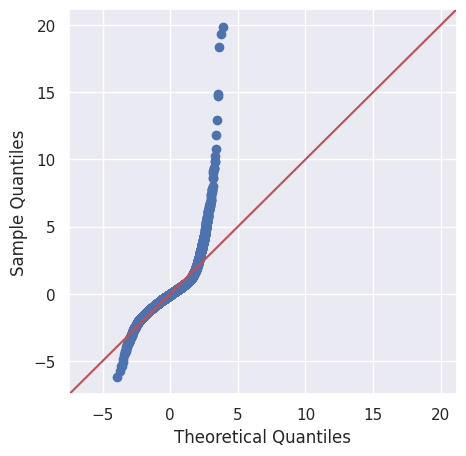

In [87]:
sns.set(rc={"figure.figsize":(5,5)})
sm.qqplot(data = m.fit().resid,
          line ='45', fit=True)
plt.show()

In [88]:
px.scatter(data_frame=kc_z, x=m.fit().fittedvalues, y=m.fit().resid, trendline='ols', trendline_color_override='black'
).update_xaxes(title='Y^').update_yaxes(title='residuals')

In [173]:
polynomial_features = PolynomialFeatures(degree=2)
kc_poly_x = polynomial_features.fit_transform(kc.drop(columns=['id', 'date', 'price', 'lat', 'long', 'sqm_above']))

In [180]:
m_poly = sm.OLS(endog=kc.price, exog=sm.add_constant(kc_poly_x))

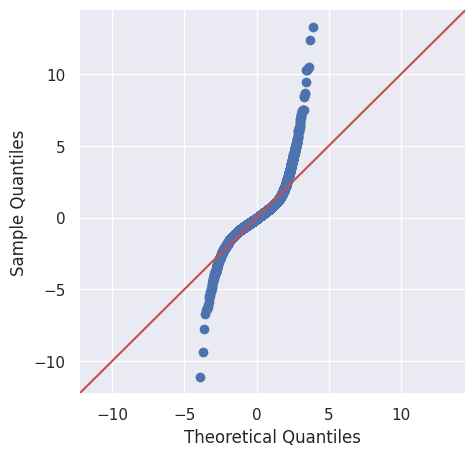

In [181]:
sns.set(rc={"figure.figsize":(5,5)})
sm.qqplot(data = m_poly.fit().resid,
          line ='45', fit=True)
plt.show()

In [182]:
px.scatter(x=m_poly.fit().fittedvalues, y=m_poly.fit().resid, trendline='ols', trendline_color_override='black'
).update_xaxes(title='Y^').update_yaxes(title='residuals')